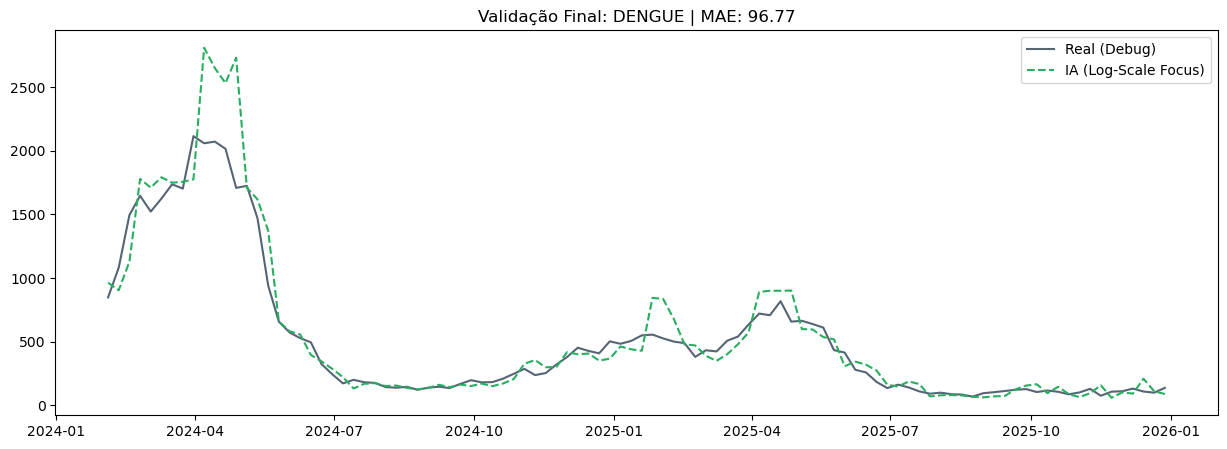

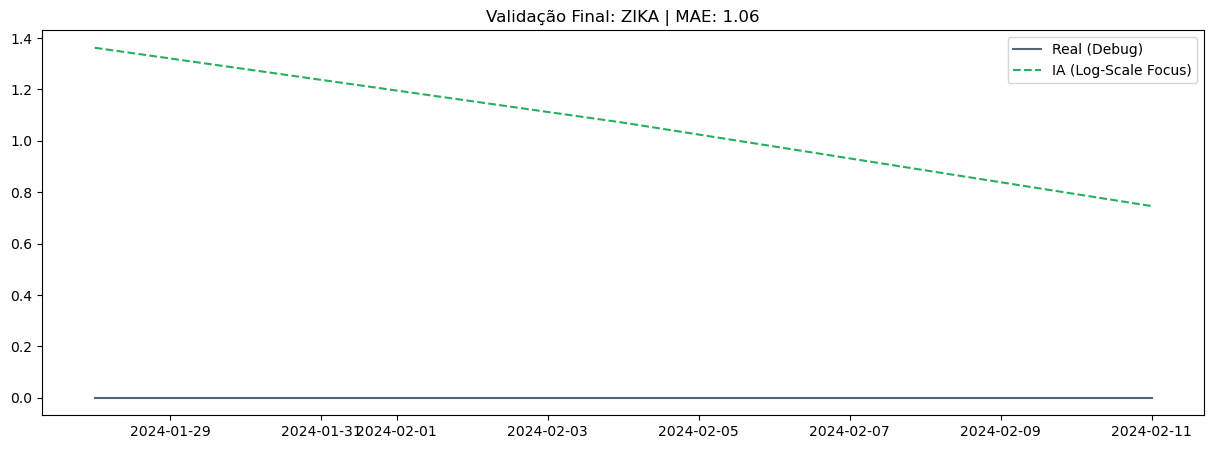

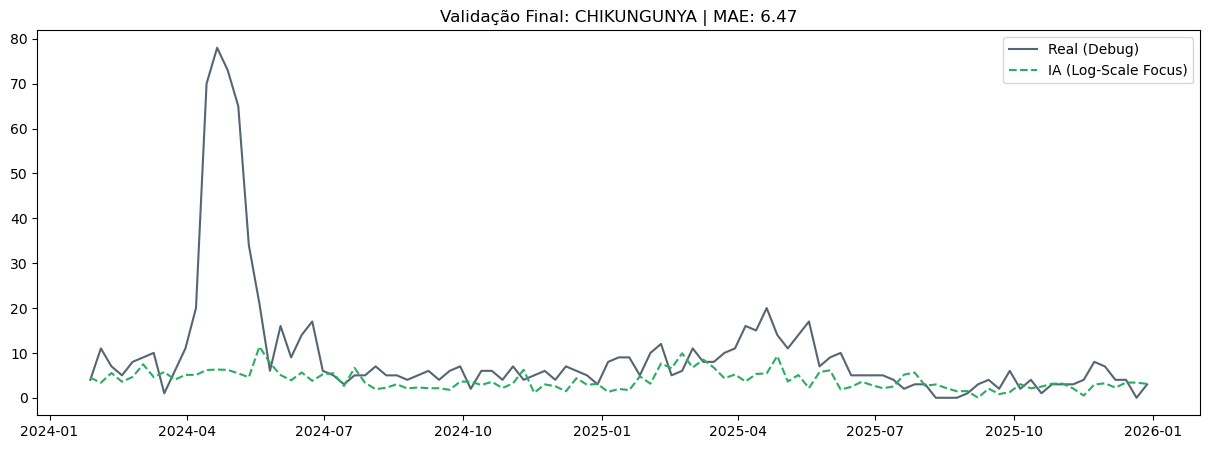

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

def preparar_dados_v3(df, date_col, casos_col):
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    
    # Criar janelas de médias móveis para suavizar ruído
    df['media_4s'] = df[casos_col].shift(1).rolling(window=4).mean()
    df['max_4s'] = df[casos_col].shift(1).rolling(window=4).max()
    
    # Diferença percentual (ajuda a prever explosões)
    df['crescimento'] = df[casos_col].shift(1) / (df[casos_col].shift(2) + 1)
    
    features = ['media_4s', 'max_4s', 'crescimento']
    
    # Lags básicos
    for i in [1, 2]:
        df[f'lag_casos_{i}'] = df[casos_col].shift(i)
        features.append(f'lag_casos_{i}')
        
    # Clima simplificado (muito lag climático gera ruído)
    if 'tempmed' in df.columns:
        df['temp_rolling'] = df['tempmed'].shift(1).rolling(window=4).mean()
        features.append('temp_rolling')
    
    if 'umidmed' in df.columns:
        df['umid_rolling'] = df['umidmed'].shift(1).rolling(window=4).mean()
        features.append('umid_rolling')

    return df.dropna(subset=features).reset_index(drop=True), features

files_train = glob.glob('data/*.csv')

for train_path in files_train:
    fname = os.path.basename(train_path)
    debug_path = os.path.join('debug', fname)
    disease_name = fname.replace('.csv', '').upper()
    
    if not os.path.exists(debug_path): continue
        
    df_train_raw = pd.read_csv(train_path)
    casos_col = 'casos' if 'casos' in df_train_raw.columns else 'casos_est'
    date_col = next((c for c in df_train_raw.columns if 'data' in c.lower()), df_train_raw.columns[0])
    
    df_train, features = preparar_dados_v3(df_train_raw, date_col, casos_col)
    
    # TÉCNICA CRUCIAL: Treinar com o Logaritmo dos casos
    # Isso faz a IA entender que o salto de 10 para 80 é TÃO importante quanto de 1000 para 2000
    y_train_log = np.log1p(df_train[casos_col])
    
    modelo = XGBRegressor(
        n_estimators=1500,
        learning_rate=0.02,
        max_depth=6, # Profundidade menor evita "decorar" o passado
        tree_method="hist",
        device="cpu",
        n_jobs=-1,
        random_state=42
    )
    
    modelo.fit(df_train[features], y_train_log)
    
    df_debug_raw = pd.read_csv(debug_path)
    df_debug, _ = preparar_dados_v3(df_debug_raw, date_col, casos_col)
    
    X_debug = df_debug[features]
    y_real = df_debug[casos_col]
    
    # Predizer e depois reverter o Logaritmo
    pred_log = modelo.predict(X_debug)
    pred_debug = np.expm1(pred_log) 
    
    mae_debug = mean_absolute_error(y_real, pred_debug)
    
    plt.figure(figsize=(15, 5))
    plt.plot(df_debug[date_col], y_real.values, label='Real (Debug)', color='#2c3e50', alpha=0.8)
    plt.plot(df_debug[date_col], pred_debug, label='IA (Log-Scale Focus)', color='#27ae60', linestyle='--')
    plt.title(f'Validação Final: {disease_name} | MAE: {mae_debug:.2f}')
    plt.legend()
    plt.show()